# FILE 1B: CENTRALIZED TRAINING -- mBERT
## Completes the centralized/federated matched pair
### Same setup as File 1 (Dropout=0.4, LR=2e-5, Early Stopping) + fp32 fix

**Estimated time: ~20 min on T4 x2**

**After disconnect:** Run Cell 1 only, then continue from where you stopped

## ⚡ Cell 1: COMPLETE SETUP -- Run after any disconnect

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, copy, time, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    precision_score, recall_score,
    matthews_corrcoef, confusion_matrix
)
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader

CKPT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_MULTI_GPU = torch.cuda.device_count() > 1

class DeceptionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df['text'].fillna('').tolist()
        self.labels = df['is_deceptive'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

class AttentionDeceptionClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.4):
        super().__init__()
        # NOTE: some HF checkpoints (e.g. the mMiniLM distillation of XLM-R-Large
        # used for the DistilXLM-R backbone) ship fp16 weights by default, which
        # raises "mat1 and mat2 must have the same dtype, but got Half and Float"
        # once combined with this float32 classifier head. Forcing float32 at
        # load time avoids that mismatch for every backbone (see Section 3.3.5
        # of the thesis, "Precision Handling").
        self.encoder = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32).float()
        h = self.encoder.config.hidden_size
        self.attention_pool = nn.Sequential(
            nn.Linear(h, 256), nn.Tanh(), nn.Linear(256, 1)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(h, 256), nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, 2)
        )
    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state
        scores = self.attention_pool(hidden)
        scores = scores.masked_fill(attention_mask.unsqueeze(-1) == 0, -1e9)
        pooled = (hidden * torch.softmax(scores, dim=1)).sum(dim=1)
        return self.classifier(pooled)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['label'].to(device)
            logits = model(ids, mask)
            loss   = criterion(logits, lbls)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = logits.argmax(dim=1)
            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return {
        'loss':      total_loss / len(loader),
        'acc':       accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall':    recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1':        f1_score(all_labels, all_preds, average='macro'),
        'f1_w':      f1_score(all_labels, all_preds, average='weighted'),
        'auc':       roc_auc_score(all_labels, all_probs),
        'mcc':       matthews_corrcoef(all_labels, all_preds),
        'preds':     all_preds,
        'labels':    all_labels,
    }

def train_model(model_name, label, epochs=5, batch_size=32, lr=2e-5, patience=2):
    ckpt_path    = f'{CKPT_DIR}/{label}_best.pt'
    results_path = f'{CKPT_DIR}/{label}_results.json'

    if os.path.exists(results_path):
        print(f'\n  checkmark  {label} already trained -- loading saved results (no retraining)')
        with open(results_path) as f:
            return json.load(f)

    print(f'\n' + '='*70)
    print(f'TRAINING: {label}')
    print(f'='*70)
    print(f'  Model:         {model_name}')
    print(f'  Max Epochs:    {epochs} (early stopping patience={patience})')
    print(f'  LR:            {lr}')
    print(f'  Dropout:       0.4')
    print(f'  Weight Decay:  0.02')

    tokenizer    = AutoTokenizer.from_pretrained(model_name)
    train_loader = DataLoader(DeceptionDataset(train_df, tokenizer), batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(DeceptionDataset(val_df,   tokenizer), batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(DeceptionDataset(test_df,  tokenizer), batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)

    model = AttentionDeceptionClassifier(model_name, dropout=0.4)
    if USE_MULTI_GPU:
        model = nn.DataParallel(model)
    model = model.to(DEVICE)

    total_steps  = len(train_loader) * epochs
    optimizer    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.02)
    scheduler    = get_linear_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)
    criterion    = nn.CrossEntropyLoss()

    best_f1    = 0
    best_state = None
    no_improve = 0
    history    = []
    t0         = time.time()

    for epoch in range(1, epochs + 1):
        print(f'\n  [EPOCH {epoch}/{epochs}]')
        print('  ' + '-'*66)
        model.train()
        train_loss = 0

        for idx, batch in enumerate(train_loader):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['label'].to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(ids, mask), lbls)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
            if (idx+1) % 50 == 0 or (idx+1) == len(train_loader):
                print(f'    Batch {idx+1}/{len(train_loader)} | Loss: {train_loss/(idx+1):.4f}')

        avg_loss = train_loss / len(train_loader)
        val_m    = evaluate(model, val_loader, criterion, DEVICE)

        print(f'\n  EPOCH {epoch} RESULTS:')
        print(f'    Train Loss: {avg_loss:.4f}')
        print(f'    Val Loss:   {val_m["loss"]:.4f}')
        print(f'    Val Acc:    {val_m["acc"]:.4f}')
        print(f'    Val F1:     {val_m["f1"]:.4f}')
        print(f'    Val AUC:    {val_m["auc"]:.4f}')
        print(f'    Val MCC:    {val_m["mcc"]:.4f}')

        history.append({
            'epoch': epoch, 'train_loss': avg_loss,
            'val_loss': val_m['loss'], 'val_acc': val_m['acc'],
            'val_f1': val_m['f1'], 'val_auc': val_m['auc'], 'val_mcc': val_m['mcc']
        })

        if val_m['f1'] > best_f1:
            best_f1    = val_m['f1']
            best_state = copy.deepcopy(
                model.module.state_dict() if USE_MULTI_GPU else model.state_dict()
            )
            torch.save(best_state, ckpt_path)
            no_improve = 0
            print(f'    NEW BEST saved (F1={best_f1:.4f})')
        else:
            no_improve += 1
            print(f'    No improvement ({no_improve}/{patience})')
            if no_improve >= patience:
                print(f'\n  EARLY STOPPING at epoch {epoch}')
                break

    if USE_MULTI_GPU:
        model.module.load_state_dict(torch.load(ckpt_path))
    else:
        model.load_state_dict(torch.load(ckpt_path))

    test_m  = evaluate(model, test_loader, criterion, DEVICE)
    elapsed = (time.time() - t0) / 60

    print(f'\n  Training time: {elapsed:.1f} min')
    print(f'  FINAL TEST RESULTS:')
    print(f'    Accuracy:      {test_m["acc"]:.4f}')
    print(f'    Precision:     {test_m["precision"]:.4f}')
    print(f'    Recall:        {test_m["recall"]:.4f}')
    print(f'    F1 (Macro):    {test_m["f1"]:.4f}  <- MAIN METRIC')
    print(f'    F1 (Weighted): {test_m["f1_w"]:.4f}')
    print(f'    AUC-ROC:       {test_m["auc"]:.4f}')
    print(f'    MCC:           {test_m["mcc"]:.4f}')

    results = {
        'model': label,
        'accuracy': float(test_m['acc']),
        'precision': float(test_m['precision']),
        'recall': float(test_m['recall']),
        'macro_f1': float(test_m['f1']),
        'weighted_f1': float(test_m['f1_w']),
        'auc_roc': float(test_m['auc']),
        'mcc': float(test_m['mcc']),
        'history': history,
        'train_minutes': elapsed,
        'preds': [int(x) for x in test_m['preds']],
        'labels': [int(x) for x in test_m['labels']],
    }
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)

    del model, tokenizer, train_loader, val_loader, test_loader
    torch.cuda.empty_cache()
    return results

print('='*70)
print('SETUP COMPLETE - ALL FUNCTIONS READY')
print('='*70)
print(f'Device:     {DEVICE}')
print(f'Multi-GPU:  {USE_MULTI_GPU}')
print(f'Checkpoint: {CKPT_DIR}')
print()
print('IF NETWORK DISCONNECTED:')
print('  1. Re-run ONLY this cell (Cell 1)')
print('  2. Re-run Cell 2 (load data)')
print('  3. Continue from the training cell')
print('  4. Already-trained model will be SKIPPED automatically')
print('='*70)

SETUP COMPLETE - ALL FUNCTIONS READY
Device:     cuda
Multi-GPU:  True
Checkpoint: /kaggle/working/checkpoints

IF NETWORK DISCONNECTED:
  1. Re-run ONLY this cell (Cell 1)
  2. Re-run Cell 2 (load data)
  3. Continue from the training cell
  4. Already-trained model will be SKIPPED automatically


## Cell 2: Load Data (re-run after disconnect)
Uses the exact same `random_state=42` split as File 1, so this model's test set is identical to XLM-RoBERTa/BanglishBERT/MuRIL's.

In [2]:
DATASET_NAME = 'YOUR_DATASET_NAME'  # <- UPDATE THIS (same dataset used for File 1)

task_files = {
    'fake_news':            f'/kaggle/input/datasets/foysal2004042/againth/fake_news_sampled_multilingual.csv',
    'product_reviews':      f'/kaggle/input/datasets/foysal2004042/againth/product_reviews_sampled_multilingual.csv',
    'phishing':             f'/kaggle/input/datasets/foysal2004042/againth/phishing_sampled_multilingual.csv',
    'political_statements': f'/kaggle/input/datasets/foysal2004042/againth/political_statements_sampled_multilingual.csv',
    'job_scams':            f'/kaggle/input/datasets/foysal2004042/againth/job_scams_sampled_multilingual.csv',
}

print('Loading data...')
dfs = []
for task, path in task_files.items():
    try:
        df = pd.read_csv(path)
        df['task'] = task
        dfs.append(df)
        print(f'  ok {task:<25} {len(df):>6,} rows')
    except FileNotFoundError:
        print(f'  FAIL {task} NOT FOUND')

df_all = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp_df = train_test_split(df_all, test_size=0.30, random_state=42, stratify=df_all['is_deceptive'])
val_df, test_df   = train_test_split(temp_df, test_size=0.6667, random_state=42, stratify=temp_df['is_deceptive'])

print(f'\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('Data ready -- same 42-seeded split as File 1, so results stay comparable')

Loading data...
  ok fake_news                  6,496 rows
  ok product_reviews            2,238 rows
  ok phishing                   1,654 rows
  ok political_statements       1,394 rows
  ok job_scams                  1,216 rows

Train: 9,098 | Val: 1,299 | Test: 2,601
Data ready -- same 42-seeded split as File 1, so results stay comparable


## Cell 3: Train mBERT (~20 min)

In [3]:
results_mbert = train_model(
    model_name = 'google-bert/bert-base-multilingual-cased',
    label      = 'mBERT',
    epochs     = 5,
    batch_size = 32,
    lr         = 2e-5,
    patience   = 2
)
print('mBERT F1:', results_mbert['macro_f1'])


TRAINING: mBERT
  Model:         google-bert/bert-base-multilingual-cased
  Max Epochs:    5 (early stopping patience=2)
  LR:            2e-05
  Dropout:       0.4
  Weight Decay:  0.02


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  [EPOCH 1/5]
  ------------------------------------------------------------------
    Batch 50/285 | Loss: 0.6887
    Batch 100/285 | Loss: 0.6678
    Batch 150/285 | Loss: 0.6341
    Batch 200/285 | Loss: 0.6055
    Batch 250/285 | Loss: 0.5767
    Batch 285/285 | Loss: 0.5598

  EPOCH 1 RESULTS:
    Train Loss: 0.5598
    Val Loss:   0.4825
    Val Acc:    0.7421
    Val F1:     0.7351
    Val AUC:    0.8631
    Val MCC:    0.5127
    NEW BEST saved (F1=0.7351)

  [EPOCH 2/5]
  ------------------------------------------------------------------
    Batch 50/285 | Loss: 0.4014
    Batch 100/285 | Loss: 0.3966
    Batch 150/285 | Loss: 0.3855
    Batch 200/285 | Loss: 0.3848
    Batch 250/285 | Loss: 0.3799
    Batch 285/285 | Loss: 0.3769

  EPOCH 2 RESULTS:
    Train Loss: 0.3769
    Val Loss:   0.4084
    Val Acc:    0.7806
    Val F1:     0.7805
    Val AUC:    0.8919
    Val MCC:    0.5615
    NEW BEST saved (F1=0.7805)

  [EPOCH 3/5]
  -------------------------------------------

## Cell 4: Save Result (ready to merge into All_Result_Merge.xlsx)

In [4]:
# Load from checkpoint (safe even after disconnect)
results_mbert = json.load(open(f'{CKPT_DIR}/mBERT_results.json'))

summary = pd.DataFrame([
    {'Model': 'mBERT', 'Learning Mode': 'Centralized', 'Best Round': '-',
      'Accuracy': results_mbert['accuracy'], 'Precision': results_mbert['precision'],
      'Recall': results_mbert['recall'], 'F1-Macro': results_mbert['macro_f1'],
      'AUC-ROC': results_mbert['auc_roc'], 'MCC': results_mbert['mcc']},
])

pd.set_option('display.float_format', '{:.4f}'.format)
print('=' * 70)
print('mBERT CENTRALIZED RESULT')
print('=' * 70)
print(summary.to_string(index=False))

with open('/kaggle/working/results_mbert.json', 'w') as f:
    json.dump({'mBERT': results_mbert}, f, indent=2)
summary.to_csv('/kaggle/working/centralized_mbert_result.csv', index=False)

print('\nSaved: results_mbert.json and centralized_mbert_result.csv')
print('\nNEXT STEPS:')
print('  1. Download both files from /kaggle/working/')
print('  2. Append this row to your existing All_Result_Merge.xlsx')
print('     (same columns as your XLM-RoBERTa / BanglishBERT / MuRIL rows)')
print('  3. This completes the centralized/federated matched pair for mBERT')

mBERT CENTRALIZED RESULT
Model Learning Mode Best Round  Accuracy  Precision  Recall  F1-Macro  AUC-ROC    MCC
mBERT   Centralized          -    0.8181     0.8181  0.8181    0.8181   0.9182 0.6363

Saved: results_mbert.json and centralized_mbert_result.csv

NEXT STEPS:
  1. Download both files from /kaggle/working/
  2. Append this row to your existing All_Result_Merge.xlsx
     (same columns as your XLM-RoBERTa / BanglishBERT / MuRIL rows)
  3. This completes the centralized/federated matched pair for mBERT


## Cell 5: Training Curve

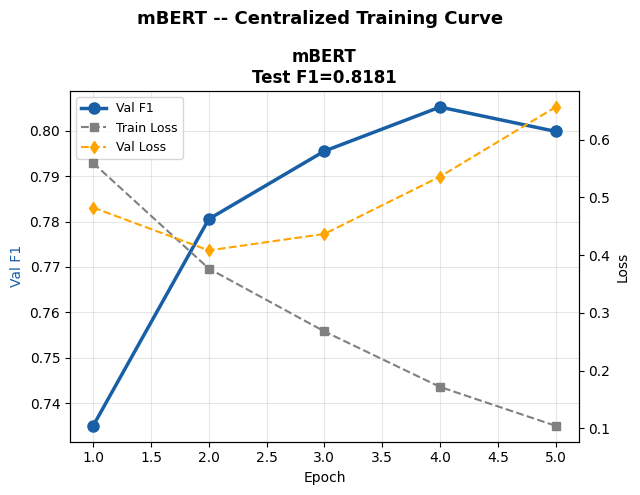

Saved: mbert_training_curve.png


In [5]:
res = json.load(open(f'{CKPT_DIR}/mBERT_results.json'))

fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
ax2 = ax.twinx()

epochs_list = [h['epoch']      for h in res['history']]
f1_list     = [h['val_f1']     for h in res['history']]
tl_list     = [h['train_loss'] for h in res['history']]
vl_list     = [h['val_loss']   for h in res['history']]

ax.plot(epochs_list, f1_list, 'o-', color='#185FA5', linewidth=2.5, markersize=8, label='Val F1')
ax2.plot(epochs_list, tl_list, 's--', color='gray',   linewidth=1.5, label='Train Loss')
ax2.plot(epochs_list, vl_list, 'd--', color='orange', linewidth=1.5, label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val F1', color='#185FA5')
ax2.set_ylabel('Loss')
ax.set_title(f'mBERT\nTest F1={res["macro_f1"]:.4f}', fontweight='bold')
ax.grid(True, alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.suptitle('mBERT -- Centralized Training Curve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/mbert_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mbert_training_curve.png')